In [1]:
# !pip install tensorflow
# !pip install numpy
# !pip install matplotlib
# !pip install pillow


In [2]:
# !pip install --upgrade setuptools

In [3]:
import tensorflow as tf
import numpy as np
from PIL import Image
from tensorflow.keras.preprocessing import image
from tensorflow.keras import models
from tensorflow.keras.models import Model


tf.compat.v1.enable_eager_execution()

In [10]:
img = image.load_img(r"C:\Users\awebb\Documents\Programming\Python\MANTIS\output_images\l2r\sample_0.jpg", target_size=(150, 150))
img_tensor = image.img_to_array(img)

In [11]:
model = tf.keras.models.load_model(r'C:\Users\awebb\Documents\Programming\Python\MANTIS\models\temp_model.keras')

In [12]:
resized_input = tf.expand_dims(tf.image.resize(img_tensor, [30, 42]), axis=0)

tf.nn.softmax(model.predict(resized_input))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step


<tf.Tensor: shape=(1, 2), dtype=float32, numpy=array([[0.993473  , 0.00652696]], dtype=float32)>

In [13]:
dummy_input = tf.random.normal([30, 42, 3])
dummy_input = tf.expand_dims(dummy_input, axis=0)
model(dummy_input)


<tf.Tensor: shape=(1, 2), dtype=float32, numpy=array([[ 0.05445546, -0.05860304]], dtype=float32)>

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
(1, 30, 42, 3)
(30, 42, 3)
(30, 42, 3)
(30, 42, 3)


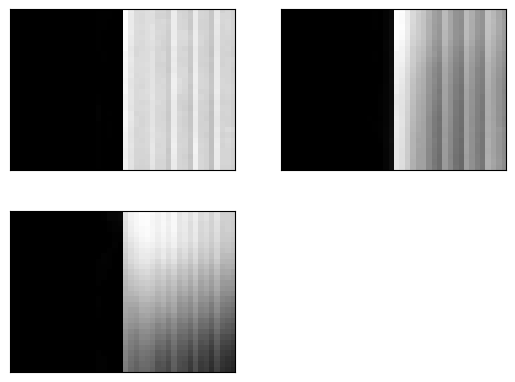

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
(1, 30, 42, 32)
(30, 42, 32)
(30, 42, 32)
(30, 42, 32)
(30, 42, 32)
(30, 42, 32)
(30, 42, 32)
(30, 42, 32)
(30, 42, 32)
(30, 42, 32)
(30, 42, 32)
(30, 42, 32)
(30, 42, 32)
(30, 42, 32)
(30, 42, 32)
(30, 42, 32)
(30, 42, 32)
(30, 42, 32)
(30, 42, 32)
(30, 42, 32)
(30, 42, 32)
(30, 42, 32)
(30, 42, 32)
(30, 42, 32)
(30, 42, 32)
(30, 42, 32)
(30, 42, 32)
(30, 42, 32)
(30, 42, 32)
(30, 42, 32)
(30, 42, 32)
(30, 42, 32)
(30, 42, 32)


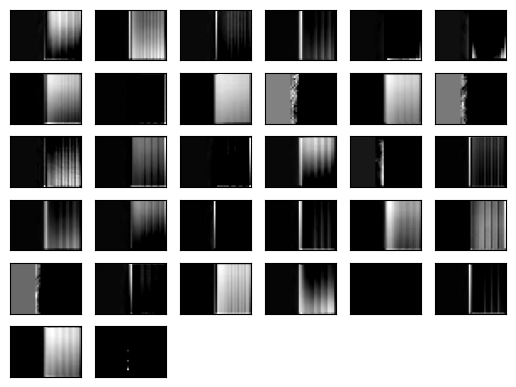

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
(1, 15, 21, 32)
(15, 21, 32)
(15, 21, 32)
(15, 21, 32)
(15, 21, 32)
(15, 21, 32)
(15, 21, 32)
(15, 21, 32)
(15, 21, 32)
(15, 21, 32)
(15, 21, 32)
(15, 21, 32)
(15, 21, 32)
(15, 21, 32)
(15, 21, 32)
(15, 21, 32)
(15, 21, 32)
(15, 21, 32)
(15, 21, 32)
(15, 21, 32)
(15, 21, 32)
(15, 21, 32)
(15, 21, 32)
(15, 21, 32)
(15, 21, 32)
(15, 21, 32)
(15, 21, 32)
(15, 21, 32)
(15, 21, 32)
(15, 21, 32)
(15, 21, 32)
(15, 21, 32)
(15, 21, 32)


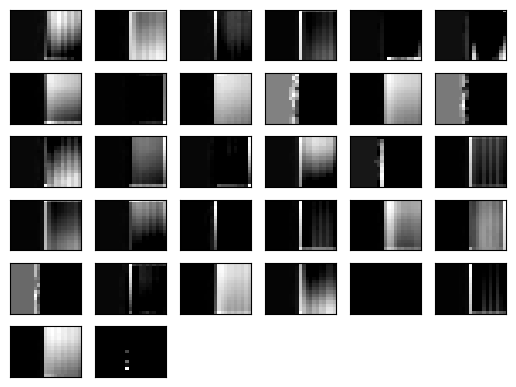

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
(1, 10080)
too many indices for array: array is 2-dimensional, but 3 were indexed
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
(1, 256)
too many indices for array: array is 2-dimensional, but 3 were indexed
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
(1, 256)
too many indices for array: array is 2-dimensional, but 3 were indexed
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
(1, 2)
too many indices for array: array is 2-dimensional, but 3 were indexed


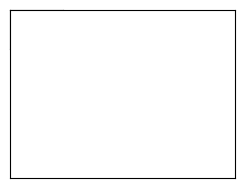

In [18]:
import matplotlib.pyplot as plt


# plt.subplots(3, 4, figsize=(20, 20))




for i in range(len(model.layers)):
    layer = model.layers[i]
    # if 'conv' not in layer.name:
    #     continue

    layer = Model(inputs=model.inputs, outputs=layer.output)
    feature_maps = layer.predict(resized_input)
    print(feature_maps.shape)
    
    # Get the number of feature maps
    n_features = feature_maps.shape[-1]
    
    # Calculate the size of the square grid
    square = min(8, int(np.ceil(np.sqrt(n_features))))
    
    ix = 1
    try: 
        for _ in range(square):
            for _ in range(square):
                if ix > n_features:  # Skip if we've shown all features
                    break
                ax = plt.subplot(square, square, ix)
                ax.set_xticks([])
                ax.set_yticks([])
                print(feature_maps[0, :, :].shape)
                plt.imshow(feature_maps[0, :, :, ix-1], cmap='gray')
                ix += 1
        plt.show()

    except Exception as e:
        print(e)
    # break
    
    